EXPERIMENT 07 - TASK 01
Model Validation
Name    : R. Karthik
Roll No : 25EU02904

Dataset Shape: (768, 9)

80/20 Holdout Accuracy: 75.97%

10-Fold Cross-Validation Scores:
[0.8052 0.7532 0.7143 0.8701 0.7922 0.7273 0.7532 0.7662 0.7895 0.7237]

Mean CV Accuracy: 76.95%
CV Standard Deviation: 4.45%


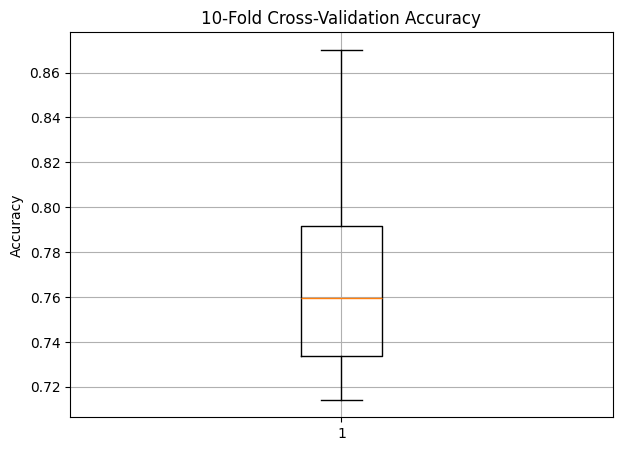


Validation Comparison:
       Validation Method  Accuracy (%)
  80/20 Train-Test Split         75.97
10-Fold Cross-Validation         76.95

TASK 01 COMPLETED
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 07 - TASK 01
# Train-Test Split and K-Fold Cross-Validation
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("=" * 60)
print("EXPERIMENT 07 - TASK 01")
print("Model Validation")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# Load Pima dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

print("\nDataset Shape:", df.shape)

# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

predictions = model.predict(
    X_test
)

holdout_accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"\n80/20 Holdout Accuracy: "
    f"{holdout_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# 10-Fold Stratified Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n10-Fold Cross-Validation Scores:")
print(
    np.round(cv_scores, 4)
)

print(
    f"\nMean CV Accuracy: "
    f"{cv_scores.mean() * 100:.2f}%"
)

print(
    f"CV Standard Deviation: "
    f"{cv_scores.std() * 100:.2f}%"
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    cv_scores
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "10-Fold Cross-Validation Accuracy"
)

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Validation Method": [
        "80/20 Train-Test Split",
        "10-Fold Cross-Validation"
    ],
    "Accuracy (%)": [
        holdout_accuracy * 100,
        cv_scores.mean() * 100
    ]
})

print("\nValidation Comparison:")
print(
    comparison.round(2).to_string(
        index=False
    )
)

print("\n" + "=" * 60)
print("TASK 01 COMPLETED")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)